# Power-to-Form - pipeline walkthrough (how the code works)

This notebook explains the **mechanics of the pipeline itself** - the data contract, the atomic
operators, the regime recipes, and the measurement - *not* the paper's research findings.

It runs entirely on a small **synthetic** district, so no licensed data is needed. The same code
path is what runs on the five real Shanghai districts; only the input data is swapped (see
`data/README.md`). The seven steps of the engine are:

```
1 select   subdistrict()               a jiedao polygon
2 clip     build_cache/load_buildings  footprints + heights clipped to it  -> recs
3 assign   assign_all (cascade)        one building = one stakeholder (EULUC->function->AOI)
4 recipe   regimes.yaml                pick a power regime (= a recipe of operators)
5 apply    apply_regime                apply operators in order -> new form
6 measure  measure.diagnose            FAR / coverage / CV / grain / slenderness / concentration
7 render   render.py                   plan / 3D / interactive HTML
```

This walkthrough covers steps 2-6 (the computational core).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "engine"))
sys.path.insert(0, str(ROOT / "data" / "synthetic"))

import matplotlib.pyplot as plt
import pandas as pd
import pf_common as C          # step 1-3: data contract + stakeholder cascade
import operators as OP         # step 4-5: the atomic verbs + apply_regime
import measure as M            # step 6: the morphological fingerprint
from make_synthetic import make

# point the engine at a synthetic district and build it
C.DATA = ROOT / "data" / "synthetic"
make(outdir=C.DATA / "demo")
print("engine loaded; synthetic district built at", C.DATA / "demo")

# activate inline AFTER importing pf_common (which sets the Agg backend)
get_ipython().run_line_magic("matplotlib","inline")


engine loaded; synthetic district built at /sessions/hopeful-affectionate-albattani/mnt/Urban-Stakeholder-Workshop/power-to-form/data/synthetic/demo


## Step 2 - the data contract: what a *building record* is

`load_buildings(slug)` reads the cached parquet and returns a plain list of dicts - the unit every
operator and metric works on. Each record is:

- `geom` - a shapely polygon in a **projected** CRS (metres), so areas and distances are real;
- `h` - building height in metres (the grammar's *conservation currency*);
- `sh` - the stakeholder class (`state` / `developer` / `resident` / `unknown`);
- `frozen` - whether an operator is allowed to touch it.

No classes, no hidden state - just geometry + height + a label.

In [2]:
recs = C.load_buildings("demo")
print(len(recs), "building records\n")
r = recs[0]
print({k: (f"<{v.geom_type}, area={v.area:.0f} m2>" if k == "geom" else v) for k, v in r.items()})

80 building records

{'geom': '<Polygon, area=499 m2>', 'h': 8.200349066928332, 'sh': 'resident', 'frozen': False}


## Step 3 - the stakeholder cascade (the *lookup principle*)

Interpretation lives in a **plain, editable table**, never in trained weights. `assign_stakeholder`
walks a priority cascade - first source that matches decides:

1. **EULUC** parcel class (`501` administrative -> state, `201` business-office -> developer, `101` residential -> resident),
2. the **building-function** layer, then
3. **AOI** keywords.

Changing the table *is* a way of arguing about the city. Here is the head of that lookup, and the
resulting share of each stakeholder in our synthetic stock.

In [3]:
lk = C.load_lookup()
print("cascade order:", lk["cascade"])
print("EULUC ->", lk["euluc"])
from collections import Counter
print("\nstakeholder shares:", dict(Counter(r["sh"] for r in recs)))

cascade order: ['euluc', 'function', 'aoi']
EULUC -> {'行政办公用地': 'state', '教育科研用地': 'state', '医疗卫生用地': 'state', '体育与文化用地': 'state', '公园与绿地用地': 'state', '交通场站用地': 'state', '机场设施用地': 'state', '商务办公用地': 'developer', '商业服务用地': 'developer', '工业用地': 'developer', '居住用地': 'resident'}

stakeholder shares: {'resident': 50, 'unknown': 3, 'developer': 15, 'state': 12}


## Step 4 - the atomic operators (the nine verbs)

Each operator is a pure `recs -> recs` transformation. Footprint verbs change plan (`slim`,
`split_to_towers`, `infill`, `open_ground`); height verbs change section (`weight_height`,
`concentrate`, `densify`, `level`); `freeze` locks stakeholders out of later steps. Several are
**floor-area-conserving by construction** - e.g. `slim` shrinks a footprint toward its centroid and
raises the height to compensate, so single-building GFA is preserved.

Below: `slim` on the resident/developer stock. Watch footprints shrink while total GFA stays put.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


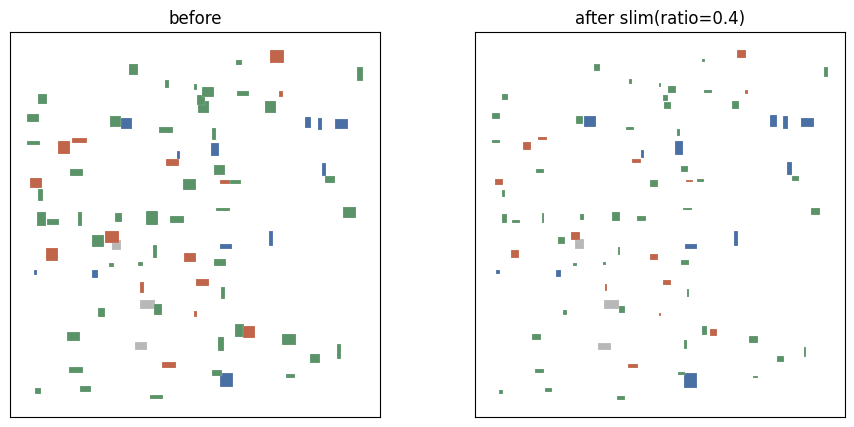

total GFA  before = 865,303   after = 865,303   (conserved to clamp)
mean height before = 17.8 m   after = 39.3 m


In [4]:
before = [dict(r) for r in recs]
after = OP.slim([dict(r) for r in recs], ["resident", "developer"], 0.4)   # ratio 0.4

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
for ax, rc, t in ((axs[0], before, "before"), (axs[1], after, "after slim(ratio=0.4)")):
    C.plot_footprints(ax, rc, lambda r: C.SH_COLOR[r["sh"]])
    ax.set_title(t)
plt.show()

print(f"total GFA  before = {C.gfa(before):,.0f}   after = {C.gfa(after):,.0f}   (conserved to clamp)")
print(f"mean height before = {sum(r['h'] for r in before)/len(before):.1f} m   "
      f"after = {sum(r['h'] for r in after)/len(after):.1f} m")

## Step 4->5 - regimes are *recipes* of operators (`config/regimes.yaml`)

A power regime is just an ordered list of operators. This is the whole "language": to describe a new
kind of power, write a new recipe - no code changes. `apply_regime` runs the steps in order.

In [5]:
reg = OP.load_regimes()
for name, recipe in reg.items():
    print(f"{name:20} = " + "  ->  ".join(s["op"] for s in recipe["steps"]))

developer_led        = freeze  ->  split_to_towers  ->  slim  ->  densify
state_led            = weight_height  ->  concentrate
resident_self_build  = freeze  ->  infill  ->  level
shared               = open_ground  ->  level


## Step 5 - apply a regime end to end

`developer_led` = `freeze(state)` -> `split_to_towers` -> `slim` -> `densify`. Public stock is frozen;
the rest is assembled into towers, slimmed, and densified. Note how the building **count** changes
(splitting/infill create new units) and how the form verticalises.

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


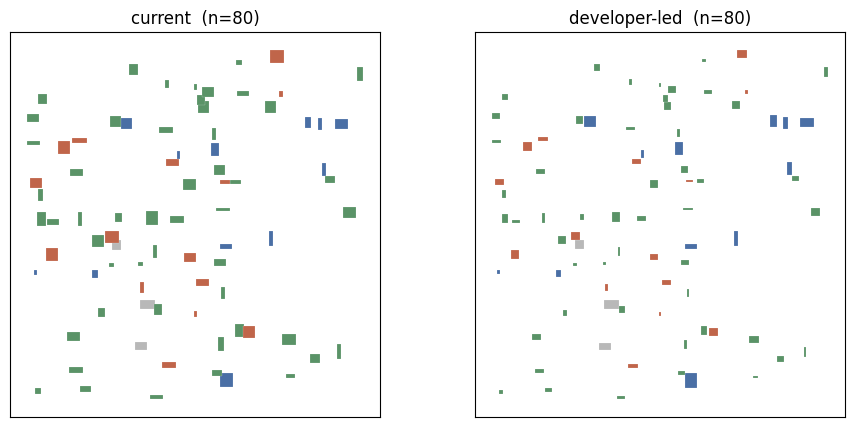

buildings: 80 -> 80
GFA:       865,303 -> 1,430,717  (+65%)


In [6]:
dev = OP.apply_regime(recs, reg["developer_led"])

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
for ax, rc, t in ((axs[0], recs, "current"), (axs[1], dev, "developer-led")):
    C.plot_footprints(ax, rc, lambda r: C.SH_COLOR[r["sh"]])
    ax.set_title(f"{t}  (n={len(rc)})")
plt.show()

print(f"buildings: {len(recs)} -> {len(dev)}")
print(f"GFA:       {C.gfa(recs):,.0f} -> {C.gfa(dev):,.0f}  ({100*(C.gfa(dev)/C.gfa(recs)-1):+.0f}%)")

## Step 6 - measure the outcome (the morphological fingerprint)

`measure.diagnose(recs, slug)` reduces any fabric to nine comparable numbers, using the same
vocabulary for observed and generated form: building count, **FAR**, ground **coverage**, mean/max
height, height **CV** (unevenness), **grain** (median footprint), **slenderness** (median h/sqrt(area)),
and **concentration** (GFA share within a fixed radius of a power centroid).

In [7]:
d = M.diagnose(recs, "demo")
for k, v in d.items():
    print(f"  {k:14} {v:.3f}")

  n              80.000
  far            0.305
  coverage       0.059
  h_mean         17.800
  h_max          49.787
  h_cv           0.538
  grain          577.193
  slender        0.681
  concentration  0.077


## Step 6 (all regimes) - `measure.compare`

`compare` diagnoses the current fabric and every regime against a **fixed reference centre** (the
current state's), so the numbers are comparable. This table is exactly what the paper's regime
signatures are read from - here on synthetic data.

,n,far,coverage,h_mean,h_cv,grain,slender
current,80.0,0.31,0.06,17.80,0.54,577.19,0.68
developer_led,80.0,0.50,0.03,60.83,0.65,287.86,3.45
state_led,80.0,0.32,0.06,21.15,2.11,577.19,0.31
resident_self_build,371.0,0.20,0.05,14.11,0.17,92.93,1.45
shared,80.0,0.27,0.04,24.40,0.20,383.82,1.26


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


...

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial Unicode MS


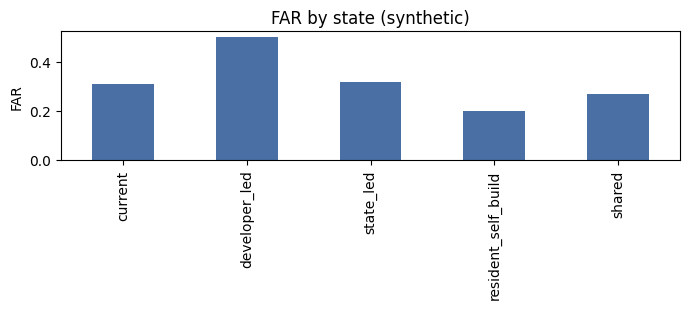

In [8]:
after_by = {name: OP.apply_regime(recs, recipe) for name, recipe in reg.items()}
rows, _ = M.compare(recs, after_by, "demo")
df = pd.DataFrame(rows).T[["n", "far", "coverage", "h_mean", "h_cv", "grain", "slender"]].round(2)
display(df)

ax = df["far"].plot(kind="bar", color="#4a6fa5", figsize=(7, 3.2), title="FAR by state (synthetic)")
ax.set_ylabel("FAR"); plt.tight_layout(); plt.show()

## From synthetic to the five real districts

Everything above is data-agnostic: swap the synthetic cache for a real one built by
`pf_common.build_cache(name, slug)` (which clips the Baidu footprints to a *jiedao* polygon and joins
EULUC / function / AOI), and the identical `apply_regime` / `measure` code produces the paper's
numbers. See `data/README.md` to rebuild the real caches, and `docs/REPRODUCIBILITY.md` for the
claim->script->output map.

**One caveat this notebook makes concrete:** our synthetic heights are *continuous*, but the real
Baidu heights are **quantised to ~6 m** (storey multiples). That quantisation is why the paper's
height-*distribution* (dip / bimodality) analysis is **withdrawn** (former section 5.4) - a dip test on
quantised heights measures the quantisation, not genuine multimodality. The operators, conservation,
substrate memory and direction signatures shown here do not depend on distribution shape and stand.
Run `python reproduce.py --verify` to see the real numbers.